In [1]:
import os
os.chdir("..")
from qwen_vl import *
import torch
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from plyfile import PlyData
from autoencoder.model_qwen import QwenAutoencoder

In [2]:
# data_path = Path('output/hypernerf/chickchicken_qwen/chickchicken_qwen_0_base/graph')
# feature_render_path = Path('output/hypernerf/chickchicken_qwen/chickchicken_qwen_0_qwenF3/video_lang/ours_10000/renders_npy/00047.npy')
# base_feature_path = Path('output/hypernerf/chickchicken_qwen/chickchicken_qwen_0_qwenF3/video_lang/ours_10000/gt_npy/00047.npy')
data_path = Path('output/cholecseg8k/video01_00080_qwen_cat/graph')
feature_render_path = Path('output/cholecseg8k/video01_00080_qwen_cat/video_lang/ours_10000/renders_npy/00047.npy')
base_feature_path = Path('output/cholecseg8k/video01_00080_qwen_cat/video_lang/ours_10000/gt_npy/00047.npy')

In [134]:
lf = np.load(data_path / "patch_latents.npy")
opacities = np.load(data_path / "opacities.npy").flatten()
pos = np.load(data_path / "positions.npy")
clusters = np.load(data_path / "clusters.npy")
colors = np.load(data_path / "colors.npy")

In [119]:
print(f"lf:        {lf.shape}")
print(f"opacities: {opacities.shape}")
print(f"pos:       {pos.shape}")
print(f"clusters:  {clusters.shape}")
print(f"colors:  {colors.shape}")

lf:        (42014, 3)
opacities: (42014,)
pos:       (42014, 3)
clusters:  (42014,)
colors:  (42014, 3)


In [120]:
feature_render = np.load(feature_render_path)[..., :3]
feature_render_norm = np.linalg.norm(feature_render, axis=-1)
base_features = np.load(base_feature_path)[..., :3]

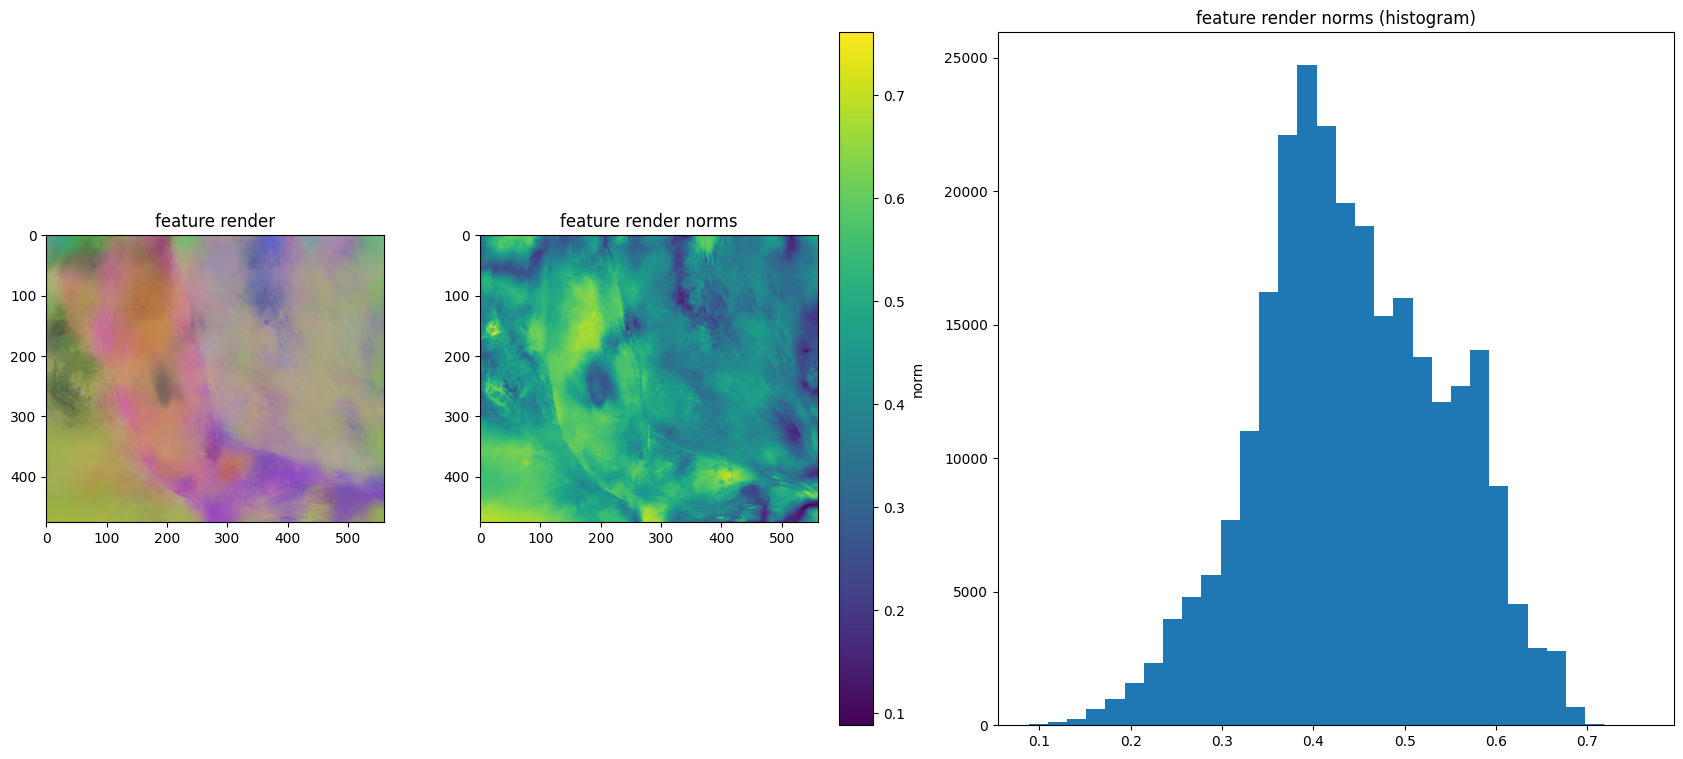

In [121]:
fig, axs = plt.subplots(1, 3, figsize=(21, 9), gridspec_kw={'width_ratios': [1, 1.25, 2]})
axs[0].imshow(feature_render / 2. + 0.5)
axs[0].set_title("feature render")
im = axs[1].imshow(feature_render_norm)
fig.colorbar(im, ax=axs[1], label="norm")
axs[1].set_title("feature render norms")
axs[2].hist(feature_render_norm.flatten(), bins=32)
axs[2].set_title("feature render norms (histogram)")
plt.show()

## Opacity stuff

In [ ]:
plt.hist(opacities, bins=32)
plt.show()

In [ ]:
fig, axs = plt.subplots(1, 2)
axs[0].hist(np.linalg.norm(lf, axis=-1))
axs[0].set_title("Latent feature norms")
plt.plot()

In [ ]:
opacities[np.argpartition(opacities, -10)[-10:]]

In [ ]:
ply_qwen = PlyData.read("output/hypernerf/chickchicken_qwen/chickchicken_qwen_0_qwenF3/point_cloud/fine-lang_iteration_10000/point_cloud.ply")['vertex']
ply_rgb = PlyData.read("output/hypernerf/chickchicken_qwen/chickchicken_qwen_0_base/point_cloud/fine-base_iteration_10000/point_cloud.ply")['vertex']

In [ ]:
np.allclose(
    np.asanyarray(ply_rgb['opacity']),
    np.asanyarray(ply_qwen['opacity']),
)

In [ ]:
ply_opacity = ply_rgb['opacity']
ply_opacity_sigmoid = torch.sigmoid(torch.as_tensor(ply_opacity)).numpy()

In [ ]:
plt.hist(ply_opacity_sigmoid, bins=32)
plt.show()

In [ ]:
plt.hist(np.asanyarray(ply_rgb['opacity']), bins=32)
plt.plot()

## Scaling experiments

In [122]:
lf_scaled_by_op = lf * opacities[:, None]
lf_normed = lf / np.linalg.norm(lf, axis=-1, keepdims=True)

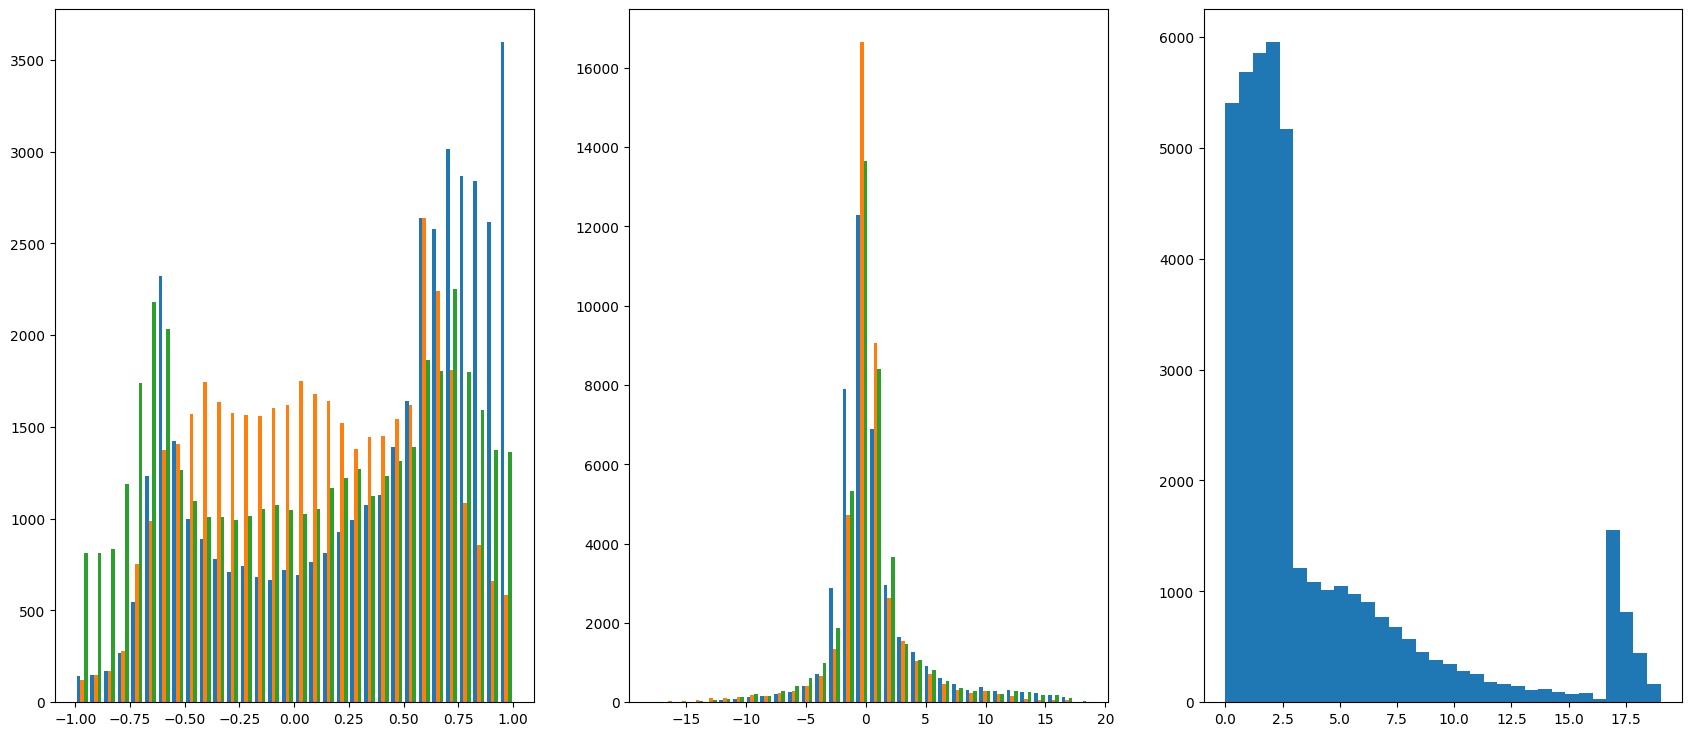

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(21, 9))
axs[0].hist(lf, bins=32)
axs[1].hist(lf_scaled_by_op, bins=32)
axs[2].hist(np.linalg.norm(lf_scaled_by_op, axis=-1), bins=32)
plt.show()

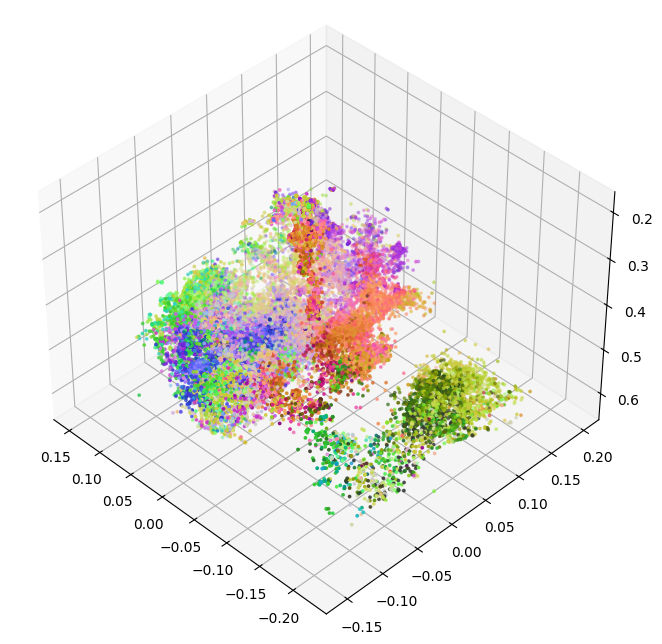

In [123]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')
ax.scatter(*pos.T, s=3, c=np.clip((lf_normed)/2+0.5, a_min=0.0, a_max=1.0))
ax.view_init(elev=-140, azim=45)
plt.show()

#TODO: looks like we're filtering based on opacity too aggressively

In [132]:
colors

array([[-0.6607161 , -1.5222923 , -1.4017899 ],
       [-0.7905323 , -1.4294305 , -1.691435  ],
       [-0.6510644 , -1.3923246 , -1.3871657 ],
       ...,
       [-0.5149531 , -1.1763325 , -1.1817191 ],
       [-0.82944757, -1.487857  , -1.4623255 ],
       [-1.1555502 , -1.793719  , -1.5247176 ]],
      shape=(42014, 3), dtype=float32)

ValueError: RGBA values should be within 0-1 range

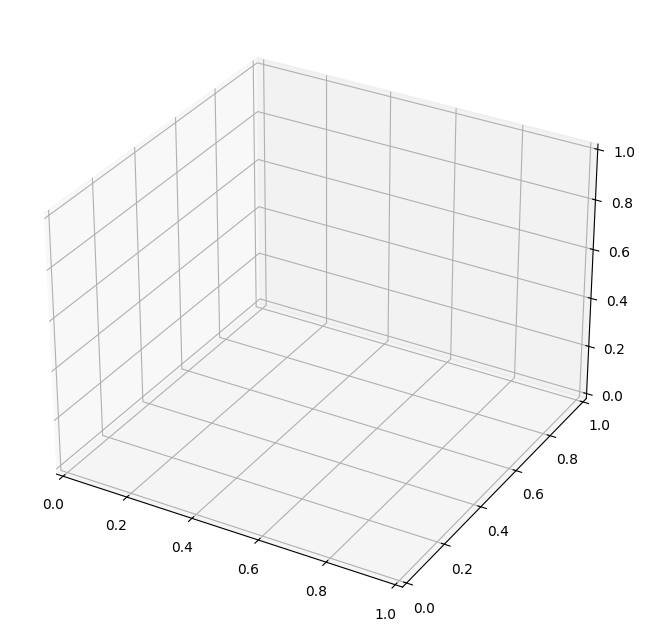

In [ ]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')
ax.scatter(*pos.T, s=3, c=c_map)
ax.view_init(elev=-140, azim=45)
plt.show()

In [137]:
gt_lf = np.load('data/cholecseg8k/preprocessed_ssg/video01/video01_00080/qwen_patch_features_dim3/000047_f.npy')
img = Image.open('data/cholecseg8k/preprocessed_ssg/video01/video01_00080/images/frame_000047.jpg')

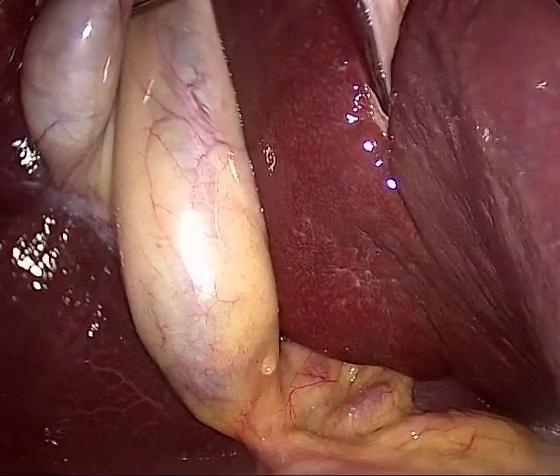

In [166]:
img

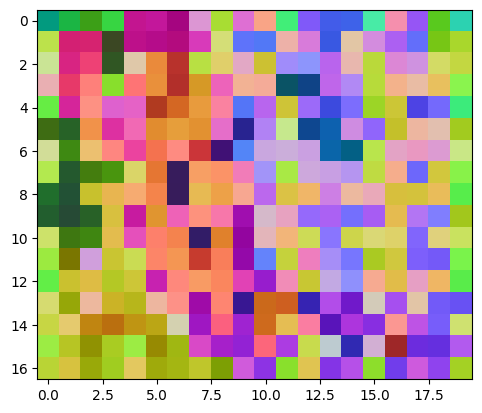

In [165]:
crop_feats = gt_lf.reshape(17, 20, 3)/2+0.5
# crop_feats = gt_lf.reshape(17, 20, 3)[6:11, :3]/2+0.5
plt.imshow(crop_feats)

In [164]:
ask_qwen_about_image_features(
    ae.decode(torch.tensor(crop_feats.reshape(-1, 3), device='cuda:1')), "Which organ is this?",
    model, processor
)

'This is the liver.'

In [ ]:
ask_qwen_about_image(img, "Describe the scene.", model, processor)

In [ ]:
ae.encode(qwen_encode_image(img, model, processor).to(torch.float32)).detach().cpu().numpy()

In [ ]:
ask_qwen_about_image_features(qwen_encode_image(img, model, processor).to(torch.float32), "Describe the scene.", model, processor)

In [ ]:
gt_lf

In [ ]:
ask_qwen_about_image_features(ae.decode(torch.tensor(gt_lf, device='cuda')), "Describe the scene.", model, processor)

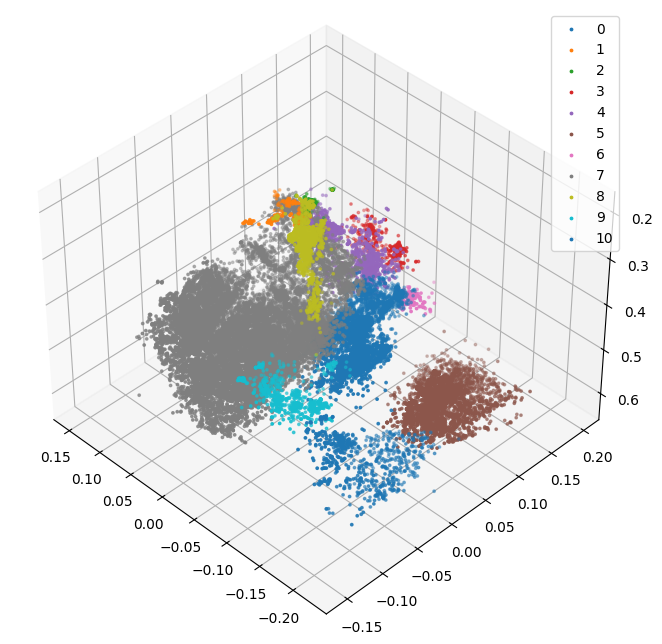

In [125]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')
for cluster_id in np.unique(clusters):
    ax.scatter(*pos[clusters == cluster_id].T, s=3, label=str(cluster_id))
ax.view_init(elev=-140, azim=45) #type:ignore
ax.legend()
plt.show()

In [126]:
selected_cluster_id = 5

cluster_feats = lf[clusters == selected_cluster_id]
cluster_pos = pos[clusters == selected_cluster_id]
mean, cov = np.mean(cluster_pos, axis=0), np.cov(cluster_pos, rowvar=False)

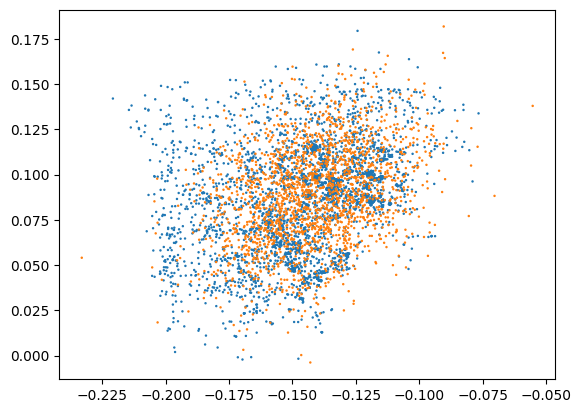

In [45]:
gaussian_sample = np.random.multivariate_normal(mean, cov, 2000, check_valid='warn')
plt.scatter(*pos[clusters == selected_cluster_id].T)
plt.scatter(*gaussian_sample.T)
plt.show()

In [129]:
L = np.linalg.cholesky(cov)
Z = np.linalg.solve(L, (cluster_pos - mean).T)
mahal_sq = np.sum(Z**2, axis=0)
log_det = 2 * np.sum(np.log(np.diag(L)))
log_norm_const = -0.5 * (3 * np.log(2 * np.pi) + log_det)
log_p = log_norm_const - 0.5 * mahal_sq
p = np.exp(2*log_p) # for squared p
probs = p / p.sum()

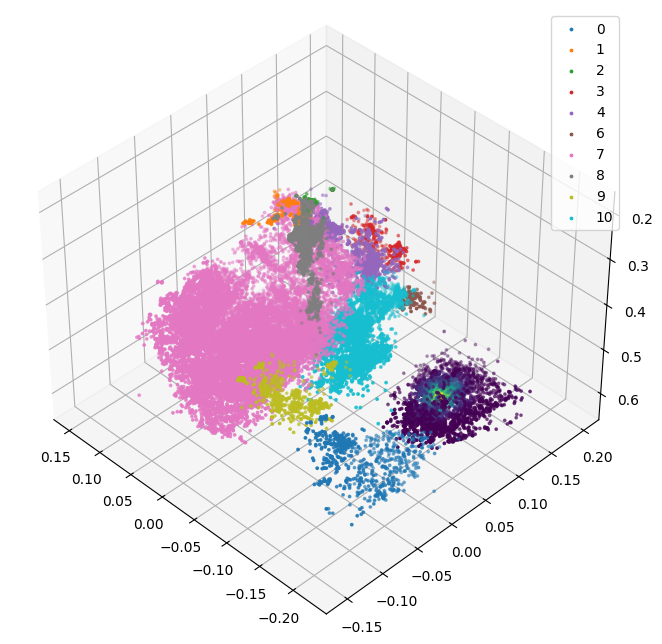

In [130]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')
for cluster_id in np.unique(clusters):
    if cluster_id == selected_cluster_id: continue
    ax.scatter(*pos[clusters == cluster_id].T, s=3, label=str(cluster_id))
ax.scatter(*pos[clusters == selected_cluster_id].T, s=3, c=probs)
ax.view_init(elev=-140, azim=45) #type:ignore
ax.legend()
plt.show()

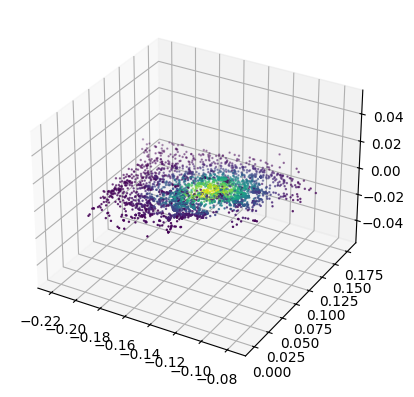

In [77]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
plt.scatter(*pos[clusters == selected_cluster_id].T, c=p)
plt.show()

In [ ]:
lf

In [12]:
model, processor = get_patched_qwen(use_bnb_4bit=False)
ae_ckpt_path = Path('data/cholecseg8k/preprocessed_ssg/video01/video01_00080/autoencoder/best_ckpt.pth')
ae = QwenAutoencoder(latent_dim=3).to("cuda:1")
ae.load_state_dict(torch.load(ae_ckpt_path))
ae.eval()
pass

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


In [ ]:
qf = torch.tensor(lf, device="cuda")
qf_normed = torch.tensor(lf_normed, device="cuda")
qf_scaled_by_op = torch.tensor(lf_scaled_by_op, device="cuda")

In [13]:
c_map = lambda c: c/2.0+0.5

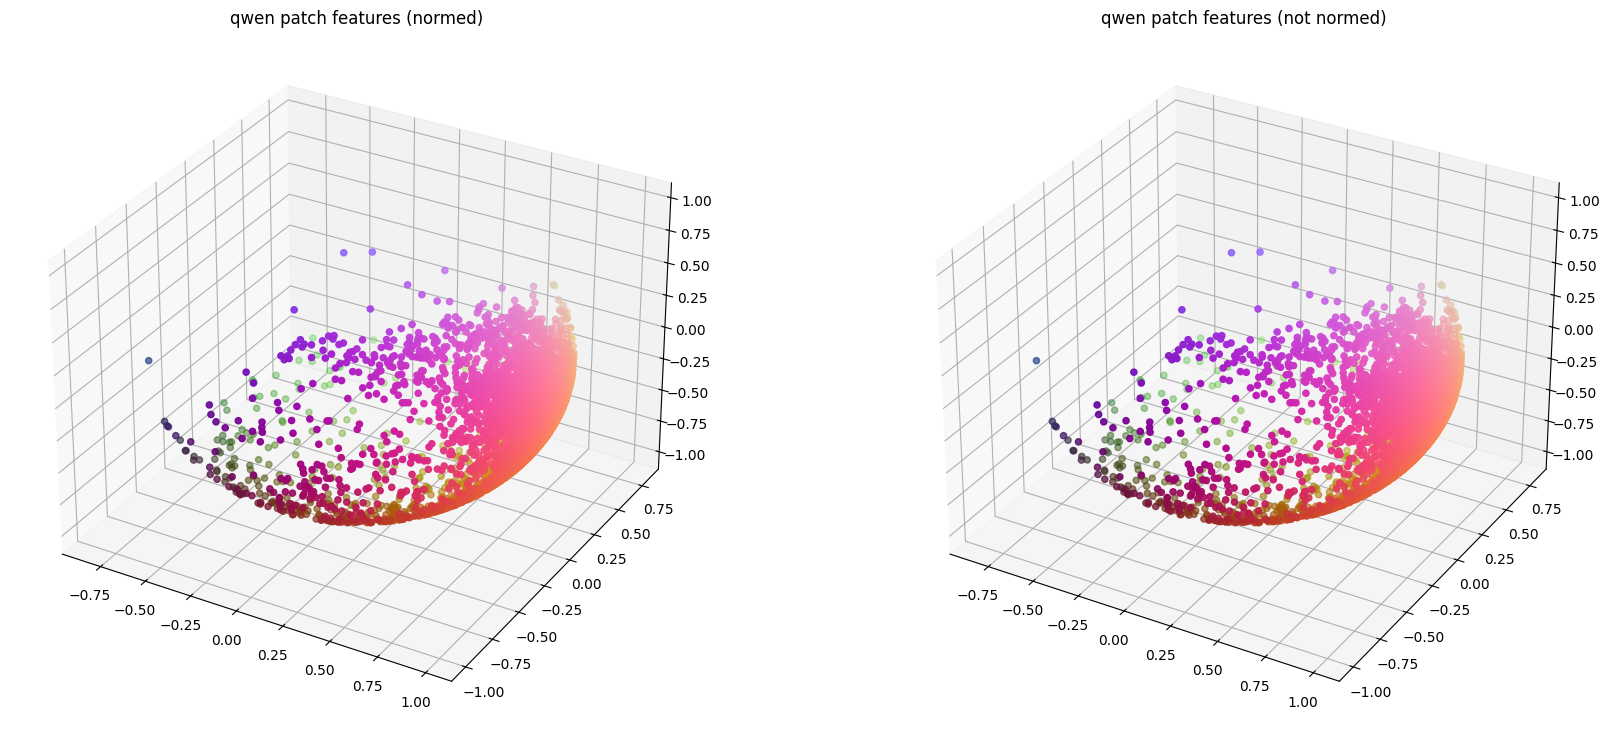

In [14]:
fig, axs = plt.subplots(1, 2, subplot_kw={'projection':'3d'}, figsize=(21, 9))
axs[0].scatter(*lf_normed[clusters == selected_cluster_id].T, c=c_map(lf_normed[clusters == selected_cluster_id]))
axs[0].set_title("qwen patch features (normed)")
axs[1].scatter(*lf[clusters == selected_cluster_id].T, c=np.clip(c_map(lf[clusters == selected_cluster_id]), a_min=0., a_max=1.))
axs[1].set_title("qwen patch features (not normed)")
plt.show()

In [ ]:
from sklearn.cluster import HDBSCAN, KMeans
kmeans = KMeans(n_clusters=200).fit(lf[clusters == selected_cluster_id])
cluster_means = kmeans.cluster_centers_
cluster_means /= np.linalg.norm(cluster_means, axis=-1, keepdims=True)
fig, axs = plt.subplots(1, 2, subplot_kw={'projection':'3d'}, figsize=(21, 9))
axs[0].scatter(*lf[clusters == selected_cluster_id].T, c=c_map(lf_normed[clusters == selected_cluster_id]))
axs[0].set_title("qwen patch features (normed)")
axs[1].scatter(*cluster_means.T, c=np.clip(c_map(cluster_means), a_min=0., a_max=1.))
axs[1].set_title("cluster means")
plt.show()

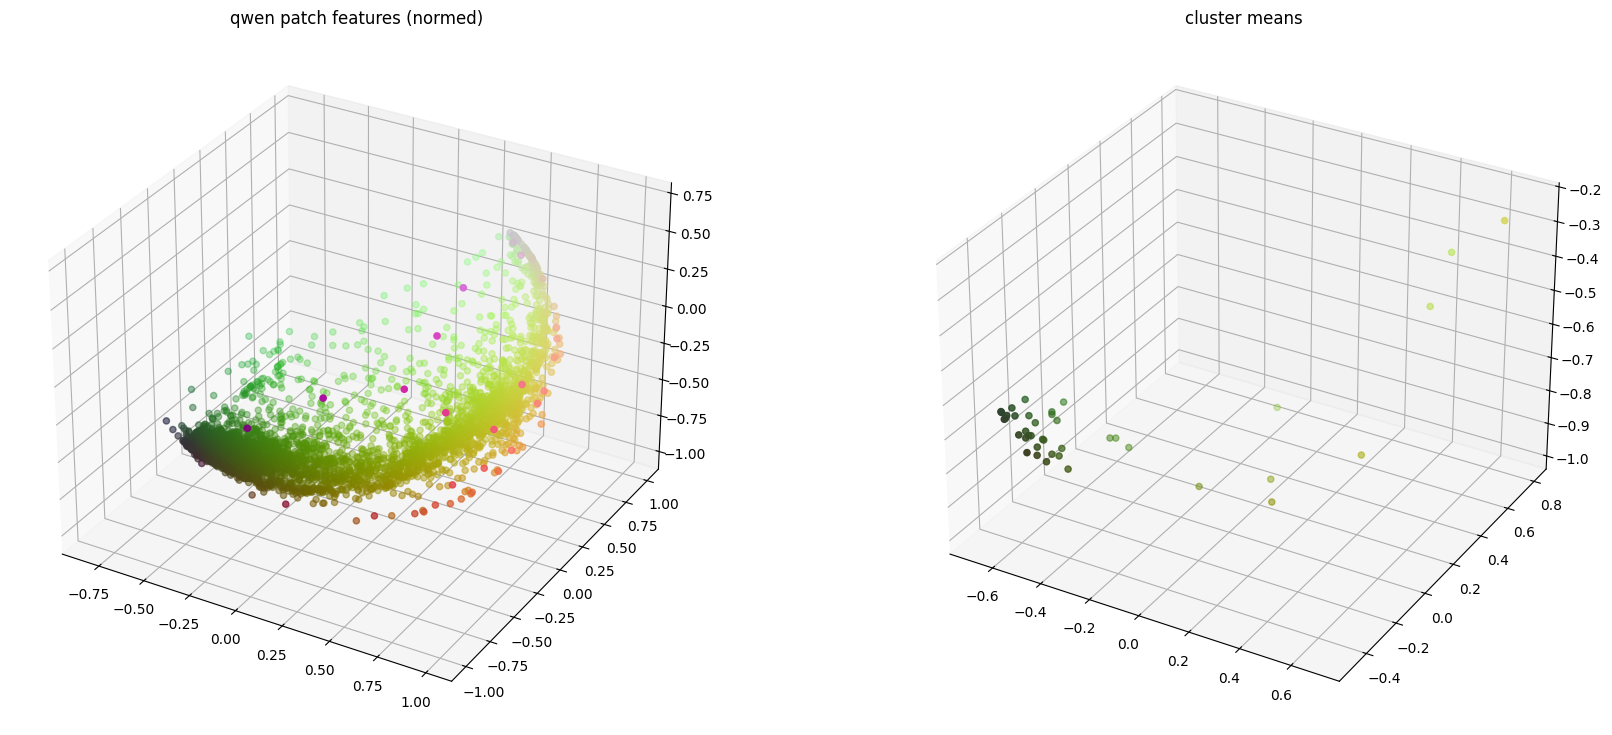

In [112]:
# random sampling based on mahalanobis density
feature_sample = cluster_feats[np.random.choice(np.arange(cluster_feats.shape[0]), 40, replace=False, p=probs)]
fig, axs = plt.subplots(1, 2, subplot_kw={'projection':'3d'}, figsize=(21, 9))
axs[0].scatter(*cluster_feats.T, c=c_map(cluster_feats))
axs[0].set_title("qwen patch features (normed)")
axs[1].scatter(*feature_sample.T, c=np.clip(c_map(feature_sample), a_min=0., a_max=1.))
axs[1].set_title("cluster means")
plt.show()

In [ ]:
plt.scatter(*cluster_pos.T)

In [114]:
ask_qwen_about_image_features(
    ae.decode(torch.tensor(feature_sample, device='cuda:1')),
    "What color is this organ?", model, processor,
    system_prompt="You are a medical assistant designed to aid medical practitioners during a cholecystectomy procedure. The surgeon user will ask you a question and show you their current situation, and you give a concise answer. Always remember to take into account the color of objects you are asked to identify."
)

'The organ in the image appears to be a light brownish-yellow color, which is typical for the gallbladder during a cholecystectomy.'

In [ ]:
from sklearn.cluster import HDBSCAN, KMeans

In [ ]:
hdb = HDBSCAN(min_cluster_size=20)
gb_feature_clusters = hdb.fit_predict(lf_normed[clusters == gb_cluster_id])

In [ ]:
hdb = HDBSCAN(min_cluster_size=20)
upper_hand_feature_clusters = hdb.fit_predict(lf_normed[clusters == upper_hand_cluster_id])

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
for subcluster_id in np.unique(gb_feature_clusters):
    ax.scatter(*lf_normed[clusters == gb_cluster_id][gb_feature_clusters == subcluster_id].T, label=str(subcluster_id))
ax.legend()
plt.show()

In [ ]:
means = []
for subcluster_id in np.unique(gb_feature_clusters)[1:]:
    feature_mean = lf_normed[clusters == gb_cluster_id][gb_feature_clusters == subcluster_id].mean(axis=0)
    means.append(feature_mean / np.linalg.norm(feature_mean))
means = np.stack(means)

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
for subcluster_id in np.unique(gb_feature_clusters):
    ax.scatter(*lf_normed[clusters == gb_cluster_id][gb_feature_clusters == subcluster_id].T, label=str(subcluster_id), depthshade=False, alpha=0.5)
ax.scatter(*means.T, c='black', depthshade=False) #type:ignore
ax.legend()
plt.show()

In [ ]:
_, counts = np.unique(gb_feature_clusters, return_counts=True)
print(f"Reduced feature count from {counts.sum()} -> {counts[0] + counts.size-1}")

In [ ]:
egg_qf = torch.tensor(means, device='cuda')

In [ ]:
hand_qf = torch.tensor(means, device='cuda')

In [ ]:
gb_qf = torch.tensor(means, device='cuda')

In [ ]:
ask_qwen_about_image_features(ae.decode(gb_qf), "Describe this image.", model, processor)

In [ ]:
gb_qf_full = torch.tensor(lf_normed[clusters == gb_cluster_id], device='cuda')

In [ ]:
# ask_qwen_about_image_features(ae.decode(gb_qf_full[torch.randint(0, gb_qf_full.shape[0], (200,))]), "Describe this image.", model, processor)
ask_qwen_about_image_features(ae.decode(gb_qf_full[torch.randint(0, gb_qf_full.shape[0], (1000,))]), "Describe this image.", model, processor)

In [ ]:
torch.randint(0, 10, (10,))

In [ ]:
hand_qf_bg = torch.tensor(lf_normed[clusters == upper_hand_cluster_id][upper_hand_feature_clusters == -1], device='cuda')
# egg_qf_bg = egg_qf_bg[torch.randint(0, egg_qf_bg.shape[0], (10,))]
centers_w_bg = torch.cat((hand_qf, hand_qf_bg), dim=0)

In [ ]:
ask_qwen_about_image_features(ae.decode(centers_w_bg), "What are the central objects visible in the image?", model, processor, system_prompt="You are a helpful assistant.")

In [ ]:
bg_features = lf_normed[clusters == gb_cluster_id][gb_feature_clusters == -1]
kmeans = KMeans(n_clusters=32, random_state=42).fit(bg_features)
means = kmeans.cluster_centers_ / np.linalg.norm(kmeans.cluster_centers_, axis=-1, keepdims=True)

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(*bg_features.T, label="BG features", depthshade=False, alpha=0.5)
ax.scatter(*means.T, c='black', depthshade=False, label="KMeans")
ax.legend()
plt.show()

In [ ]:
gb_qf_bg_kmeans = torch.tensor(means, device='cuda')
# egg_qf_bg = egg_qf_bg[torch.randint(0, egg_qf_bg.shape[0], (10,))]
centers_w_bg_kmeans = torch.cat((gb_qf, gb_qf_bg_kmeans), dim=0)

In [ ]:
ask_qwen_about_image_features(ae.decode(centers_w_bg_kmeans), "Which organ is visible here?", model, processor)